# 4B. Low Field Resonances

## Zeeman resonances and zero field resonance at very low magnetic fields.

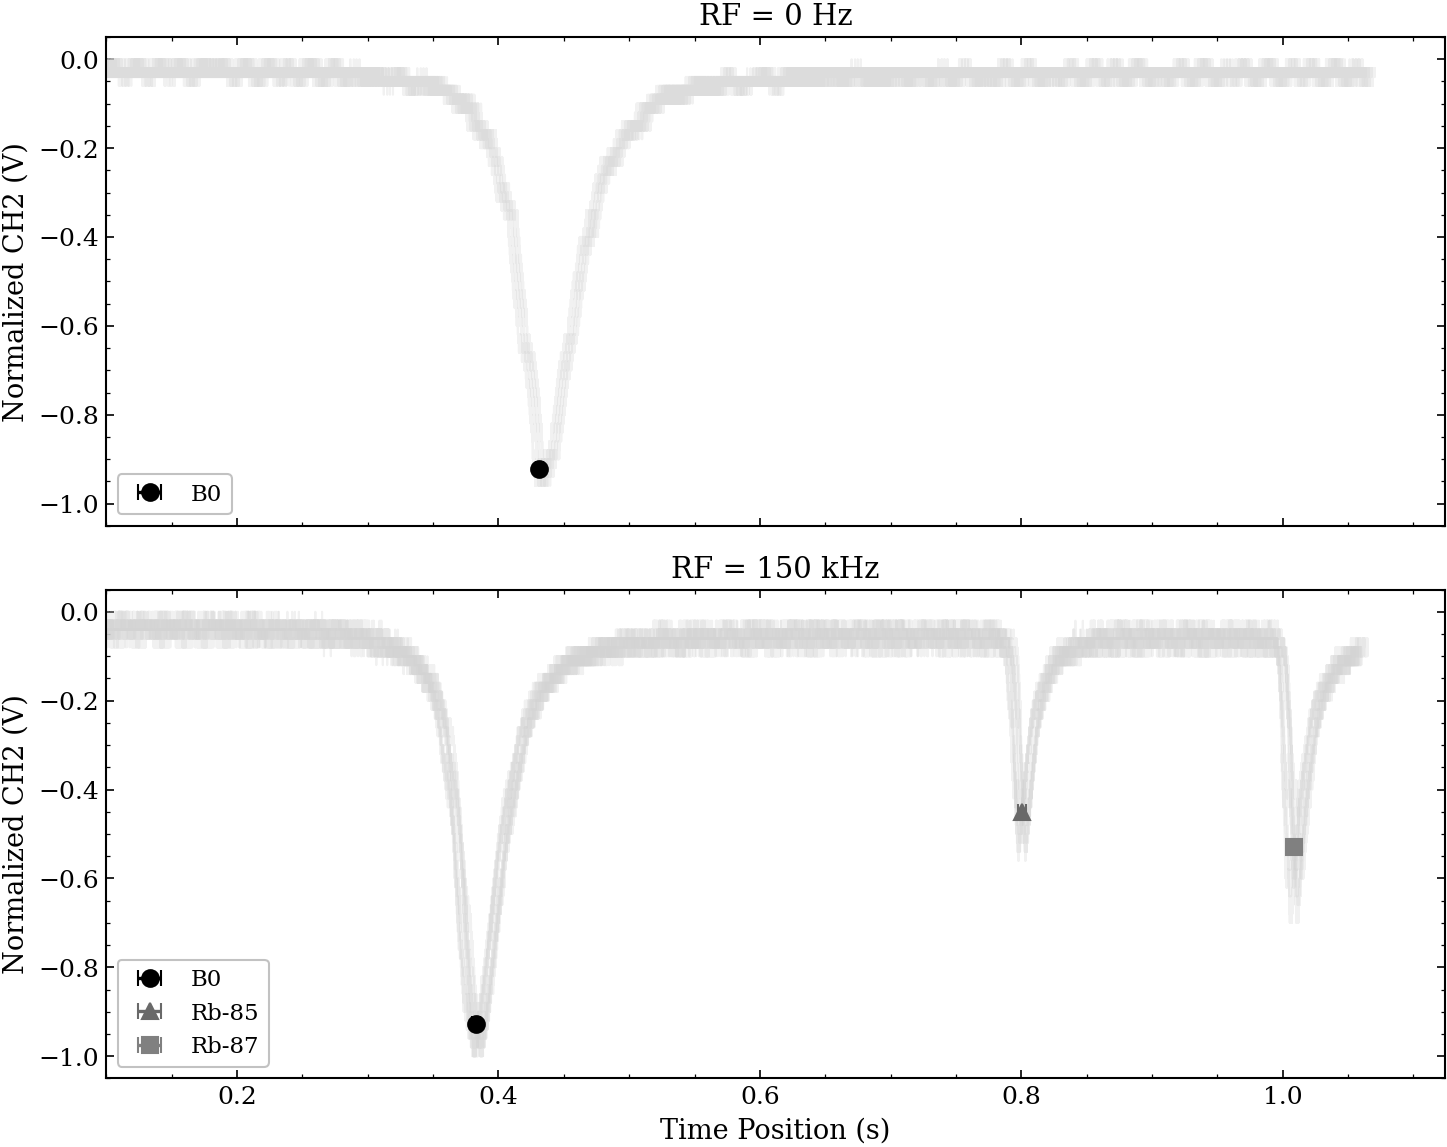

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
from scipy.signal import find_peaks

sys.path.append(os.path.abspath(".."))
from src.visualization.plot_settings import apply_plot_style, save_figure

# 1. 載入整合好的資料 (不再自己做峰值偵測)
df_d2 = pd.read_csv("../data/interim/D2.csv")

# 欲比較的兩個頻率
freqs_to_compare = [0, 150000]

# 原始檔案路徑：用來畫出每個頻率的 sweep 背景，輔助視覺比較
raw_files = {
    0: "../data/raw/D2_Optical_Pumping/0413/B0.csv",
    150000: "../data/raw/D2_Optical_Pumping/0413/150KHZ_RF.csv",
}

# 標記樣式設定 (黑白列印友善)
target_tags = ["B0", "Rb-85", "Rb-87"]
markers = {"B0": "o", "Rb-85": "^", "Rb-87": "s"}
colors = {"B0": "black", "Rb-85": "dimgray", "Rb-87": "gray"}

apply_plot_style("bw")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)
axes = {0: ax1, 150000: ax2}

for freq in freqs_to_compare:
    ax = axes[freq]
    filepath = raw_files[freq]

    # --- 繪製背景原始訊號軌跡 ---
    if os.path.exists(filepath):
        df_raw = pd.read_csv(filepath, skiprows=11)
        df_raw.columns = ["Time (s)", "CH2 (V)", "CH3 (V)"]
        t_raw = df_raw["Time (s)"].values
        ch2 = df_raw["CH2 (V)"].values
        ch3 = df_raw["CH3 (V)"].values

        # 單純利用 CH3 的最大最小值進行週期的定位
        ch3_max_idx, _ = find_peaks(ch3, prominence=1.0, distance=1000)
        ch3_min_idx, _ = find_peaks(-ch3, prominence=1.0, distance=1000)

        for m in ch3_min_idx:
            next_maxs = ch3_max_idx[ch3_max_idx > m]
            if len(next_maxs) > 0:
                end_idx = next_maxs[0]
                duration = t_raw[end_idx] - t_raw[m]
                if 0.8 < duration < 1.2:
                    t_seg = t_raw[m:end_idx]
                    c2_seg = ch2[m:end_idx]

                    # 將波形最高點(基準線)偏移到 0
                    c2_seg_normalized = c2_seg - np.max(c2_seg)

                    # 繪製平移後的訊號，不反轉
                    ax.plot(
                        t_seg - t_seg[0],
                        c2_seg_normalized,
                        color="lightgray",
                        alpha=0.3,
                        lw=1,
                    )

    # --- 從 D2.csv 把已知標記疊加到圖上 ---
    df_freq = df_d2[df_d2["RF freq."] == freq]

    for tag in target_tags:
        df_tag = df_freq[df_freq["tag"] == tag]

        # 限制範圍 x >= 0.1
        df_tag = df_tag[df_tag["time position"] >= 0.1]

        if df_tag.empty:
            continue

        # x 為時間範圍, y 為 -dip depth (向下標記)，利用已知的不確定度加入水平誤差棒
        x = df_tag["time position"].values
        xerr = df_tag["time uncertainty"].values
        y = -df_tag["dip depth"].values

        ax.errorbar(
            x,
            y,
            xerr=xerr,
            fmt=markers[tag],
            color=colors[tag],
            label=tag,
            capsize=4,
            markersize=8,
            zorder=5,
        )

    freq_label = "0 Hz" if freq == 0 else f"{freq//1000} kHz"
    ax.set_title(f"RF = {freq_label}")
    ax.set_ylabel("Normalized CH2 (V)")

    # 強制限制 X 軸呈現範圍
    ax.set_xlim(left=0.1)

    # 解決疊加時會重複渲染 Legend 標籤的問題, 改到左下角
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    if unique:
        ax.legend(unique.values(), unique.keys(), loc="lower left")

ax2.set_xlabel("Time Position (s)")
plt.tight_layout()
save_figure(fig, "4b_raw_traces_comparison.pdf", directory="../reports/figures")
plt.show()

## Low field Zeeman effect

=== Rb-85 ===
Slope = 0.463+/-0.006 MHz/A
Intercept = -0.1657+/-0.0031 MHz

=== Rb-87 ===
Slope = 0.2981+/-0.0023 MHz/A
Intercept = -0.1063+/-0.0015 MHz



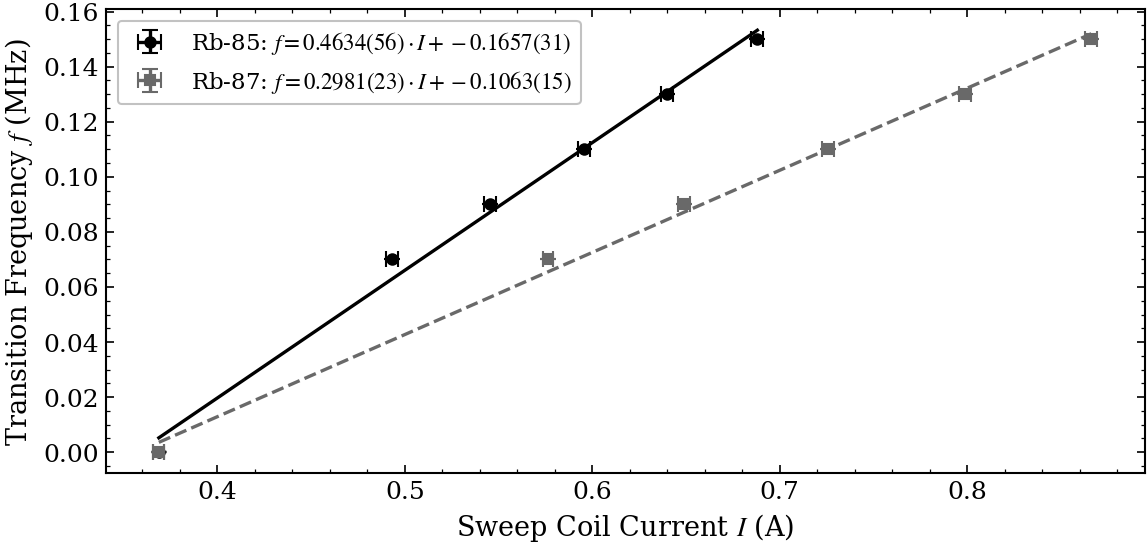

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.analysis.fitting import excel_style_regression_with_propagation
from src.analysis.formatting import ufloat_to_paren
from src.visualization.plot_settings import apply_plot_style, save_figure

# 1. Load data
df_d2 = pd.read_csv("../data/interim/D2.csv")

# 2. Filter data
target_freqs = [70000, 90000, 110000, 130000, 150000]
df_rf = df_d2[df_d2["RF freq."].isin(target_freqs)].copy()
df_0 = df_d2[df_d2["RF freq."] == 0].copy()

# 轉換為 MHz
df_rf["RF freq. MHz"] = df_rf["RF freq."] / 1e6
df_rf["RF freq. uncertainty MHz"] = 0.0

df_0["RF freq. MHz"] = 0.0
df_0["RF freq. uncertainty MHz"] = 0.0

tags = ["Rb-85", "Rb-87"]
# 黑白友善的設定：使用不同的 marker (圓形 vs 方形)、線條樣式 (實線 vs 虛線) 以及黑灰顏色
markers = {"Rb-85": "o", "Rb-87": "s"}
linestyles = {"Rb-85": "-", "Rb-87": "--"}
colors = {"Rb-85": "black", "Rb-87": "dimgray"}

apply_plot_style("bw")
fig, ax = plt.subplots(figsize=(8, 4))

for tag in tags:
    # 取得大於 0Hz 的相應同位素數據，並合併 0Hz 數據
    df_tag = df_rf[df_rf["tag"] == tag].copy()
    df_tag = pd.concat([df_tag, df_0], ignore_index=True)
    df_tag = df_tag.sort_values("CH3 current")

    if df_tag.empty:
        continue

    x = df_tag["CH3 current"].values
    sigma_x = df_tag["CH3 current uncertainty"].values
    y = df_tag["RF freq. MHz"].values
    sigma_y = df_tag["RF freq. uncertainty MHz"].values

    # 進行迴歸與不確定度傳遞
    slope, intercept = excel_style_regression_with_propagation(x, y, sigma_x, sigma_y)

    # 格式化方程式文字
    eq_label = (
        f"{tag}: $f = {ufloat_to_paren(slope)} \\cdot I + {ufloat_to_paren(intercept)}$"
    )

    print(f"=== {tag} ===")
    print(f"Slope = {slope} MHz/A")
    print(f"Intercept = {intercept} MHz")
    print()

    # 畫點 (含有誤差棒)，將方程式直接顯示於圖例(Legend)中
    ax.errorbar(
        x,
        y,
        xerr=sigma_x,
        yerr=sigma_y,
        fmt=markers[tag],
        color=colors[tag],
        label=eq_label,
        capsize=4,
    )

    # 畫擬合線
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope.nominal_value * x_fit + intercept.nominal_value
    ax.plot(x_fit, y_fit, linestyle=linestyles[tag], color=colors[tag])

ax.set_xlabel("Sweep Coil Current $I$ (A)")
ax.set_ylabel("Transition Frequency $f$ (MHz)")
# ax.set_title("Low Field Zeeman Resonances")
ax.set_title("")
ax.legend()
plt.tight_layout()
save_figure(fig, "4b_low_field_zeeman.pdf", directory="../reports/figures")
plt.show()

## Sweep field calibration

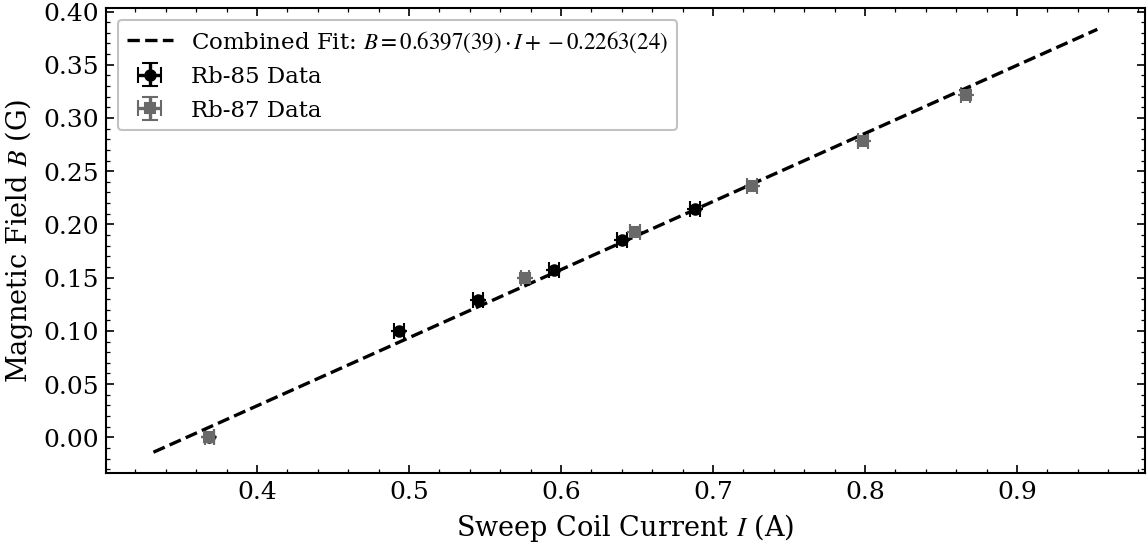

=== Sweep Field Calibration ===
Slope: 0.640+/-0.004 G/A
Intercept: -0.2263+/-0.0024 G


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.analysis.fitting import excel_style_regression_with_propagation
from src.analysis.formatting import ufloat_to_paren
from src.visualization.plot_settings import apply_plot_style, save_figure

# 物理常數
mu_b = 9.274009994e-28  # J/G
h = 6.62607015e-34  # J·s

# 理論 g_F
g_F_dict = {"Rb-85": 1 / 2, "Rb-87": 1 / 3}

# 1. Load data
df_d2 = pd.read_csv("../data/interim/D2.csv")

# 2. Filter data
target_freqs = [70000, 90000, 110000, 130000, 150000]
df_rf = df_d2[df_d2["RF freq."].isin(target_freqs)].copy()
df_0 = df_d2[df_d2["RF freq."] == 0].copy()

tags = ["Rb-85", "Rb-87"]
markers = {"Rb-85": "o", "Rb-87": "s"}
colors = {"Rb-85": "black", "Rb-87": "dimgray"}

# 準備容器用以合併變數做單一擬合
combined_currents = []
combined_currents_err = []
combined_B = []
combined_B_err = []

apply_plot_style("bw")
fig, ax = plt.subplots(figsize=(8, 4))

for tag in tags:
    # 取出該同位素的資料，並合併 0Hz 數據
    df_tag = df_rf[df_rf["tag"] == tag].copy()
    df_tag = pd.concat([df_tag, df_0], ignore_index=True)
    df_tag = df_tag.sort_values("CH3 current")

    if df_tag.empty:
        continue

    freqs = df_tag["RF freq."].values
    # 假設 RF freq. 不確定度小到可忽略
    freqs_err = np.zeros_like(freqs)

    # 取得 Sweep Coil Current 與其誤差
    I = df_tag["CH3 current"].values
    I_err = df_tag["CH3 current uncertainty"].values

    # 計算 Magnetic field B (G)
    # B = RF_freq * h / (g_F * mu_b)
    B = freqs * h / (g_F_dict[tag] * mu_b)
    B_err = freqs_err * h / (g_F_dict[tag] * mu_b)

    # 存入共用列表作後續 fit
    combined_currents.extend(I)
    combined_currents_err.extend(I_err)
    combined_B.extend(B)
    combined_B_err.extend(B_err)

    # 畫點 (含有誤差棒)
    ax.errorbar(
        I,
        B,
        xerr=I_err,
        yerr=B_err,
        fmt=markers[tag],
        color=colors[tag],
        label=f"{tag} Data",
        capsize=4,
    )

# 轉換型別以進行擬合
combined_currents = np.array(combined_currents)
combined_currents_err = np.array(combined_currents_err)
combined_B = np.array(combined_B)
combined_B_err = np.array(combined_B_err)

# 單一線性擬合：結合所有 Rb-85, Rb-87 與 0Hz 之參數校正
slope_B, intercept_B = excel_style_regression_with_propagation(
    x=combined_currents,
    y=combined_B,
    sigma_x=combined_currents_err,
    sigma_y=combined_B_err,
)

# 繪製單一擬合線，並套用 formatting
x_fit = np.linspace(combined_currents.min() * 0.9, combined_currents.max() * 1.1, 100)
y_fit = slope_B.nominal_value * x_fit + intercept_B.nominal_value

eq_label = f"Combined Fit: $B = {ufloat_to_paren(slope_B)} \\cdot I + {ufloat_to_paren(intercept_B)}$"
ax.plot(x_fit, y_fit, linestyle="--", color="black", label=eq_label)

ax.set_xlabel("Sweep Coil Current $I$ (A)")
ax.set_ylabel("Magnetic Field $B$ (G)")
# ax.set_title("Sweep Field Calibration: Magnetic Field vs. Sweep Coil Current")
ax.set_title("")
ax.legend()
plt.tight_layout()
save_figure(fig, "4b_sweep_field_calibration.pdf", directory="../reports/figures")
plt.show()

print("=== Sweep Field Calibration ===")
print(f"Slope: {slope_B} G/A")
print(f"Intercept: {intercept_B} G")

/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


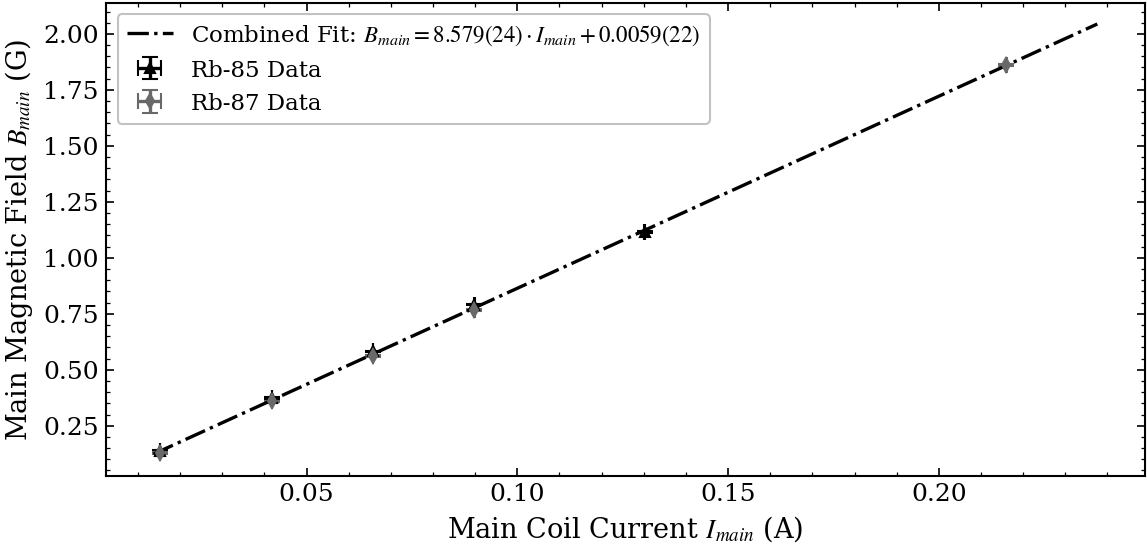

=== Main Field Calibration ===
Slope: 8.579+/-0.024 G/A
Intercept: 0.0059+/-0.0022 G


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from uncertainties import ufloat

sys.path.append(os.path.abspath(".."))
from src.analysis.fitting import excel_style_regression_with_propagation
from src.analysis.formatting import ufloat_to_paren
from src.visualization.plot_settings import apply_plot_style, save_figure

# 物理常數
mu_b = 9.274009994e-28  # J/G
h = 6.62607015e-34  # J·s

# 理論 g_F
g_F_dict = {"Rb-85": 1 / 2, "Rb-87": 1 / 3}

# 1. Load data
df_d2 = pd.read_csv("../data/interim/D2.csv")

# 2. Filter data: 針對主磁場的測試，選取頻率 >= 200kHz (亦即 200000 Hz)
df_main = df_d2[df_d2["RF freq."] >= 200000].copy()

tags = ["Rb-85", "Rb-87"]
# 使用與上個 cell 不同的 marker，同時保持黑白友善
markers = {"Rb-85": "^", "Rb-87": "d"}
colors = {"Rb-85": "black", "Rb-87": "dimgray"}

# 準備容器用以合併變數做單一擬合
combined_I_main = []
combined_I_main_err = []
combined_B_main = []
combined_B_main_err = []

apply_plot_style("bw")
fig, ax = plt.subplots(figsize=(8, 4))

for tag in tags:
    df_tag = df_main[df_main["tag"] == tag].sort_values("main field current")
    if df_tag.empty:
        continue

    freqs = df_tag["RF freq."].values
    freqs_err = np.zeros_like(freqs)

    # 取得 Sweep Coil Current (用於扣除環境磁場與 sweep 電流造成的場)
    I_sweep = df_tag["CH3 current"].values
    I_sweep_err = df_tag["CH3 current uncertainty"].values

    # 取得 Main Coil Current 也就是橫軸 x
    I_main = df_tag["main field current"].values
    I_main_err = df_tag["main field current uncertainty"].values

    # 計算此時實驗環境下的總磁場 B_total
    # B_total = freqs * h / (g_F * mu_b)
    B_tot = freqs * h / (g_F_dict[tag] * mu_b)
    B_tot_err = freqs_err * h / (g_F_dict[tag] * mu_b)

    # 扣除由 Sweep Coil 產生之磁場以及地磁背景 (利用上個 cell 算出的 slope_B, intercept_B ufloat 物件)
    # B_main = B_total - (slope_B * I_sweep + intercept_B)
    B_main_vals = []
    B_main_errs = []

    for i in range(len(I_sweep)):
        # 轉換為 ufloat 以自動計算誤差傳遞
        u_I_sweep = ufloat(I_sweep[i], I_sweep_err[i])
        u_B_tot = ufloat(B_tot[i], B_tot_err[i])

        # 扣除 Sweep Field 與 B0 intercept
        u_B_main = u_B_tot - (slope_B * u_I_sweep + intercept_B)

        B_main_vals.append(u_B_main.nominal_value)
        B_main_errs.append(u_B_main.std_dev)

    B_main_vals = np.array(B_main_vals)
    B_main_errs = np.array(B_main_errs)

    # 存入共用列表作後續綜合 fit
    combined_I_main.extend(I_main)
    combined_I_main_err.extend(I_main_err)
    combined_B_main.extend(B_main_vals)
    combined_B_main_err.extend(B_main_errs)

    # 畫點 (含有誤差棒)
    ax.errorbar(
        I_main,
        B_main_vals,
        xerr=I_main_err,
        yerr=B_main_errs,
        fmt=markers[tag],
        color=colors[tag],
        label=f"{tag} Data",
        capsize=4,
    )

# 轉換型別以進行擬合
combined_I_main = np.array(combined_I_main)
combined_I_main_err = np.array(combined_I_main_err)
combined_B_main = np.array(combined_B_main)
combined_B_main_err = np.array(combined_B_main_err)

# 單一線性擬合：B_main vs. I_main
slope_main, intercept_main = excel_style_regression_with_propagation(
    x=combined_I_main,
    y=combined_B_main,
    sigma_x=combined_I_main_err,
    sigma_y=combined_B_main_err,
)

# 繪製單一擬合線，並套用 formatting
x_fit = np.linspace(combined_I_main.min() * 0.9, combined_I_main.max() * 1.1, 100)
y_fit = slope_main.nominal_value * x_fit + intercept_main.nominal_value

eq_label = f"Combined Fit: $B_{{main}} = {ufloat_to_paren(slope_main)} \\cdot I_{{main}} + {ufloat_to_paren(intercept_main)}$"
ax.plot(x_fit, y_fit, linestyle="-.", color="black", label=eq_label)

ax.set_xlabel("Main Coil Current $I_{main}$ (A)")
ax.set_ylabel("Main Magnetic Field $B_{main}$ (G)")
# ax.set_title("Main Field Calibration: Magnetic Field vs. Main Coil Current")
ax.set_title("")
ax.legend()
plt.tight_layout()
save_figure(fig, "4b_main_field_calibration.pdf", directory="../reports/figures")
plt.show()

print("=== Main Field Calibration ===")
print(f"Slope: {slope_main} G/A")
print(f"Intercept: {intercept_main} G")